In [1]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)



TensorFlow version: 2.15.0


In [2]:
import os

print("Current folder:")
print(os.getcwd())

print("\nFiles/Folders:")
print(os.listdir())

Current folder:
C:\Users\N TECH

Files/Folders:
['.anaconda', '.android', '.antigravity-ide', '.cache', '.claude', '.claude.json', '.codex', '.conda', '.condarc', '.continuum', '.copilot', '.emulator_console_auth_token', '.expo', '.gemini', '.gradle', '.idlerc', '.ipynb_checkpoints', '.ipython', '.javacpp', '.junie', '.jupyter', '.keras', '.matplotlib', '.npmrc', '.spyder-py3', '.virtual_documents', '.vscode', '.vscode-shared', '3D Objects', 'AndroidStudioProjects', 'AppData', 'Application Data', 'battery-report.html', 'Contacts', 'Cookies', 'Deskto', 'Desktop', 'Documents', 'Downloads', 'Favorites', 'first demo.ipynb', 'flask', 'IntelGraphicsProfiles', 'Links', 'Local Settings', 'Music', 'My Documents', 'NetHood', 'node_modules', 'NTUSER.DAT', 'ntuser.dat.LOG1', 'ntuser.dat.LOG2', 'NTUSER.DAT{a4f2634b-bb98-11f0-9ba2-d616621c72f0}.TM.blf', 'NTUSER.DAT{a4f2634b-bb98-11f0-9ba2-d616621c72f0}.TMContainer00000000000000000001.regtrans-ms', 'NTUSER.DAT{a4f2634b-bb98-11f0-9ba2-d616621c72f0}.TM

In [3]:
import os

dataset_path = r"C:\Users\N TECH\Desktop\skin disease dataset\dataset"

print("Dataset exists:", os.path.exists(dataset_path))

if os.path.exists(dataset_path):
    print("\nDataset folders:")
    print(os.listdir(dataset_path))
    

Dataset exists: True

Dataset folders:
['Acne', 'Chickenpox', 'Dyshidrotic Eczema', 'Ringworm']


In [4]:
import os

dataset_path = r"C:\Users\N TECH\Desktop\skin disease dataset\dataset"

classes = os.listdir(dataset_path)

print("Number of classes:", len(classes))
print()

for class_name in classes:
    class_path = os.path.join(dataset_path, class_name)

    if os.path.isdir(class_path):
        images = [
            f for f in os.listdir(class_path)
            if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".webp"))
        ]

        print(f"{class_name}: {len(images)} images")

Number of classes: 4

Acne: 3283 images
Chickenpox: 3293 images
Dyshidrotic Eczema: 2600 images
Ringworm: 3210 images


In [5]:
import tensorflow as tf

dataset_path = r"C:\Users\N TECH\Desktop\skin disease dataset\dataset"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.20,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.20,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names

print("Classes:", class_names)
print("Number of classes:", len(class_names))

Found 12386 files belonging to 4 classes.
Using 9909 files for training.
Found 12386 files belonging to 4 classes.
Using 2477 files for validation.
Classes: ['Acne', 'Chickenpox', 'Dyshidrotic Eczema', 'Ringworm']
Number of classes: 4


In [6]:
from tensorflow.keras import layers, models
import tensorflow as tf

# Data augmentation
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.1),
])

# MobileNetV2 base model
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

# Initially freeze the pretrained model
base_model.trainable = False

# Build model
model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),
    
    data_augmentation,
    
    layers.Rescaling(1./127.5, offset=-1),
    
    base_model,
    
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(4, activation="softmax")
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()



Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sequential (Sequential)     (None, 224, 224, 3)       0         
                                                                 
 rescaling (Rescaling)       (None, 224, 224, 3)       0         
                                                                 
 mobilenetv2_1.00_224 (Func  (None, 7, 7, 1280)        2257984   
 tional)                                                         
                                                                 
 global_average_pooling2d (  (None, 1280)              0         
 GlobalAveragePooling2D)                                         
                                                                 
 dropout (Dropout)           (None, 1280)              0         
                                                                 
 dense (Dense)               (None, 128)            

In [7]:
# Train the model

EPOCHS = 10

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

Epoch 1/10


310/310 [==============================] - 239s 757ms/step - loss: 0.3383 - accuracy: 0.8610 - val_loss: 0.1935 - val_accuracy: 0.9229
Epoch 2/10
310/310 [==============================] - 226s 729ms/step - loss: 0.2194 - accuracy: 0.9080 - val_loss: 0.1907 - val_accuracy: 0.9168
Epoch 3/10
310/310 [==============================] - 225s 725ms/step - loss: 0.1906 - accuracy: 0.9198 - val_loss: 0.1510 - val_accuracy: 0.9338
Epoch 4/10
310/310 [==============================] - 226s 728ms/step - loss: 0.1764 - accuracy: 0.9250 - val_loss: 0.1398 - val_accuracy: 0.9403
Epoch 5/10
310/310 [==============================] - 227s 733ms/step - loss: 0.1691 - accuracy: 0.9281 - val_loss: 0.1987 - val_accuracy: 0.9100
Epoch 6/10
310/310 [==============================] - 227s 732ms/step - loss: 0.1639 - accuracy: 0.9328 - val_loss: 0.1462 - val_accuracy: 0.9419
Epoch 7/10
310/310 [==============================] - 220s 711ms/step - loss: 0.1562 - accuracy: 0.9365 - val_loss: 0.1169

In [8]:
import matplotlib.pyplot as plt

# Accuracy Graph
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Loss Graph
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

ModuleNotFoundError: No module named 'matplotlib'

In [11]:
!pip install matplotlib

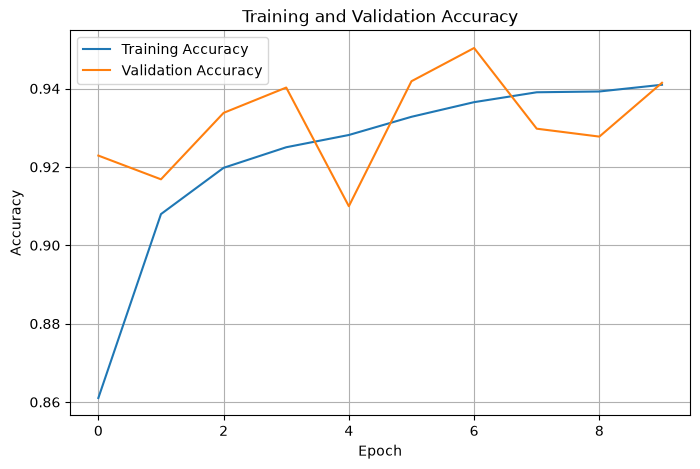

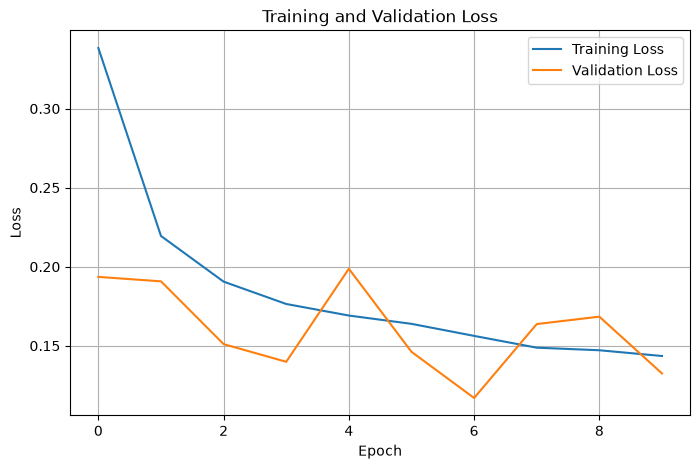

In [12]:
import matplotlib.pyplot as plt

# Accuracy Graph
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Loss Graph
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [13]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import seaborn as sns

# Predict on test data
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

# Classification Report
print("="*50)
print("CLASSIFICATION REPORT")
print("="*50)
print(classification_report(y_true, y_pred_classes))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix', fontsize=14)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.show()

ModuleNotFoundError: No module named 'sklearn'

In [14]:
!pip install scikit-learn seaborn

  Using cached joblib-1.6.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached narwhals-2.25.0-py3-none-any.whl.metadata (15 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached cloudpickle-3.1.2-py3-none-any.whl.metadata (7.1 kB)
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.3 MB 1.5 MB/s eta 0:00:06
   ------ --------------------------------- 1.3/8.3 MB 2.8 MB/s eta 0:00:03
   ----------- ---------------------------- 2.4/8.3 MB 3.7 MB/s eta 0:00:02
   ------------------- -------------------- 3.9/8.3 MB 4.6 MB/s eta 0:00:01
   ------------------------- -------------- 5.2/8.3 MB 5.1 MB/s eta 0:00:01
   -------------------------------- ------- 6.8/8.3 MB 5.4 MB/s eta 0:00:01
   ---------------------------------------  8.1/8.3 MB 5.7 MB/s eta 0:00:01
   ---------------------------------------- 8.3/8.3 MB 5.5 MB/s  

In [15]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Predict on test data
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

# Classification Report
print("="*60)
print("CLASSIFICATION REPORT")
print("="*60)
print(classification_report(y_true, y_pred_classes))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names if 'class_names' in dir() else None,
            yticklabels=class_names if 'class_names' in dir() else None)
plt.title('Confusion Matrix', fontsize=14)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.show()

# Additional Metrics
print("\n" + "="*60)
print("ADDITIONAL METRICS")
print("="*60)

# Per-class accuracy
correct = np.diag(cm)
total = np.sum(cm, axis=1)
per_class_acc = correct / total

for i, acc in enumerate(per_class_acc):
    print(f"Class {i} Accuracy: {acc:.4f}")

print(f"\nOverall Accuracy: {np.sum(correct) / np.sum(cm):.4f}")

NameError: name 'X_test' is not defined

In [16]:
# Check available variables
print("Available variables:")
print("="*40)

# Try to find test data variables
try:
    print(f"X_test exists: {'X_test' in dir()}")
except:
    print("X_test: Not found")

try:
    print(f"y_test exists: {'y_test' in dir()}")
except:
    print("y_test: Not found")

try:
    print(f"x_test exists: {'x_test' in dir()}")
except:
    print("x_test: Not found")

try:
    print(f"test_images exists: {'test_images' in dir()}")
except:
    print("test_images: Not found")

try:
    print(f"test_labels exists: {'test_labels' in dir()}")
except:
    print("test_labels: Not found")

# Show all variables that might contain test data
print("\n" + "="*40)
print("All variables with 'test' in name:")
for var in dir():
    if 'test' in var.lower():
        print(f"  - {var}")

Available variables:
X_test exists: False
y_test exists: False
x_test exists: False
test_images exists: False
test_labels exists: False

All variables with 'test' in name:


In [19]:
# Check what we have
print("CHECKING AVAILABLE DATA")
print("="*40)

# Check if model exists
try:
    print(f"✅ Model exists: {model is not None}")
except:
    print("❌ Model not found")

# Check for training data
try:
    print(f"✅ X_train exists: {X_train.shape if 'X_train' in dir() else 'No'}")
except:
    print("❌ X_train not found")

try:
    print(f"✅ y_train exists: {y_train.shape if 'y_train' in dir() else 'No'}")
except:
    print("❌ y_train not found")

# Check all variables
print("\n" + "="*40)
print("ALL VARIABLES IN NOTEBOOK:")
print("-"*40)
for var in dir():
    if not var.startswith('_'):  # Skip private variables
        print(f"  {var}")

CHECKING AVAILABLE DATA
✅ Model exists: True
✅ X_train exists: No
✅ y_train exists: No

ALL VARIABLES IN NOTEBOOK:
----------------------------------------
  BATCH_SIZE
  EPOCHS
  IMG_SIZE
  In
  Out
  SEED
  base_model
  class_name
  class_names
  class_path
  classes
  classification_report
  confusion_matrix
  data_augmentation
  dataset_path
  exit
  get_ipython
  history
  images
  layers
  model
  models
  np
  open
  os
  plt
  quit
  sns
  tf
  train_ds
  val_ds
  var


In [20]:
# Check dataset info
print("DATASET INFORMATION")
print("="*40)

# Check train dataset
print(f"Train dataset: {train_ds}")
try:
    for images, labels in train_ds.take(1):
        print(f"  Batch shape: {images.shape}")
        print(f"  Labels shape: {labels.shape}")
        print(f"  Number of classes: {len(set(labels.numpy()))}")
except:
    print("  Could not inspect train_ds")

# Check validation dataset
print(f"\nValidation dataset: {val_ds}")
try:
    for images, labels in val_ds.take(1):
        print(f"  Batch shape: {images.shape}")
        print(f"  Labels shape: {labels.shape}")
except:
    print("  Could not inspect val_ds")

# Check class names
print(f"\nClass names: {class_names}")
print(f"Number of classes: {len(class_names)}")

DATASET INFORMATION
Train dataset: <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>
  Batch shape: (32, 224, 224, 3)
  Labels shape: (32,)
  Number of classes: 4

Validation dataset: <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>
  Batch shape: (32, 224, 224, 3)
  Labels shape: (32,)

Class names: ['Acne', 'Chickenpox', 'Dyshidrotic Eczema', 'Ringworm']
Number of classes: 4


Predicting on validation data...
  Processed 10 batches...
  Processed 20 batches...
  Processed 30 batches...
  Processed 40 batches...
  Processed 50 batches...
  Processed 60 batches...
  Processed 70 batches...

✅ Total validation samples: 2477

CLASSIFICATION REPORT (on Validation Data)
                    precision    recall  f1-score   support

              Acne       0.88      0.92      0.90       635
        Chickenpox       1.00      0.99      0.99       645
Dyshidrotic Eczema       0.88      0.87      0.88       538
          Ringworm       1.00      0.98      0.99       659

          accuracy                           0.94      2477
         macro avg       0.94      0.94      0.94      2477
      weighted avg       0.94      0.94      0.94      2477



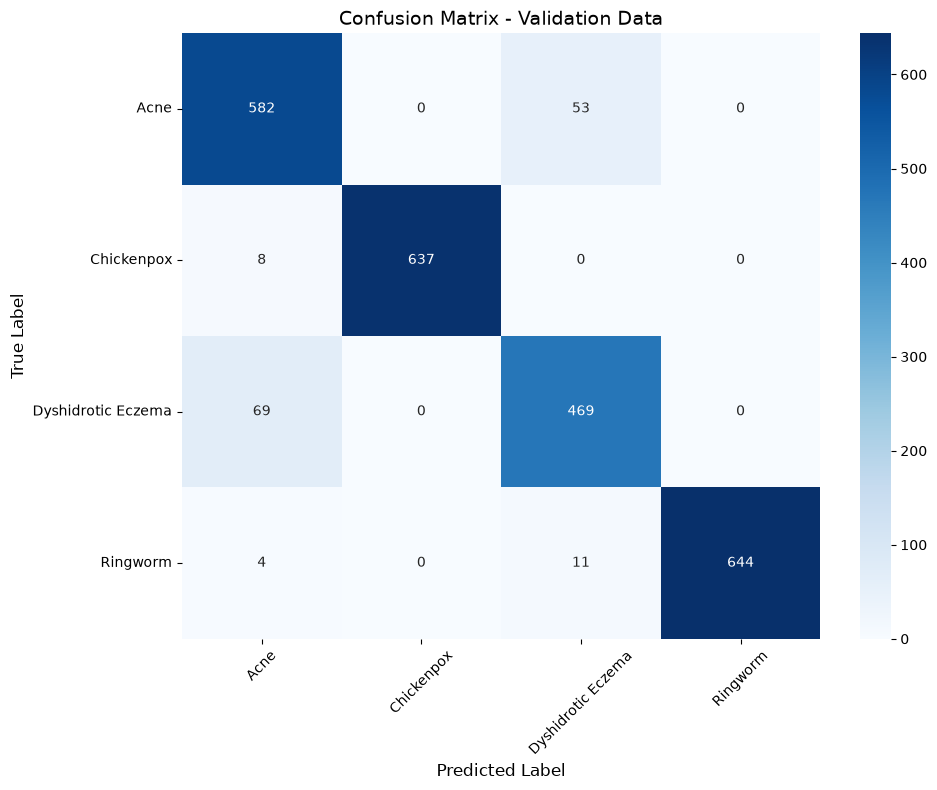


PER-CLASS ACCURACY
Acne: 0.9165 (582/635)
Chickenpox: 0.9876 (637/645)
Dyshidrotic Eczema: 0.8717 (469/538)
Ringworm: 0.9772 (644/659)

✅ Overall Validation Accuracy: 0.9415


In [21]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Get all predictions and true labels from validation set
y_true = []
y_pred_classes = []

print("Predicting on validation data...")
print("="*40)

# Count total batches
total_batches = 0
for images, labels in val_ds:
    total_batches += 1
    # Predict
    predictions = model.predict(images, verbose=0)
    predicted_classes = np.argmax(predictions, axis=1)
    
    # Store
    y_true.extend(labels.numpy())
    y_pred_classes.extend(predicted_classes)
    
    # Show progress
    if total_batches % 10 == 0:
        print(f"  Processed {total_batches} batches...")

# Convert to numpy arrays
y_true = np.array(y_true)
y_pred_classes = np.array(y_pred_classes)

print(f"\n✅ Total validation samples: {len(y_true)}")

# Classification Report
print("\n" + "="*60)
print("CLASSIFICATION REPORT (on Validation Data)")
print("="*60)
print(classification_report(y_true, y_pred_classes, target_names=class_names))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, 
            yticklabels=class_names)
plt.title('Confusion Matrix - Validation Data', fontsize=14)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Per-class accuracy
correct = np.diag(cm)
total_per_class = np.sum(cm, axis=1)
per_class_acc = correct / total_per_class

print("\n" + "="*60)
print("PER-CLASS ACCURACY")
print("="*60)
for i, acc in enumerate(per_class_acc):
    print(f"{class_names[i]}: {acc:.4f} ({correct[i]}/{total_per_class[i]})")

print(f"\n✅ Overall Validation Accuracy: {np.sum(correct) / np.sum(cm):.4f}")

In [22]:
# Get predictions on training data for comparison
y_true_train = []
y_pred_train = []

print("Predicting on training data...")
print("="*40)

total_batches = 0
for images, labels in train_ds:
    total_batches += 1
    predictions = model.predict(images, verbose=0)
    predicted_classes = np.argmax(predictions, axis=1)
    
    y_true_train.extend(labels.numpy())
    y_pred_train.extend(predicted_classes)
    
    if total_batches % 10 == 0:
        print(f"  Processed {total_batches} batches...")

y_true_train = np.array(y_true_train)
y_pred_train = np.array(y_pred_train)

# Training accuracy
train_accuracy = np.mean(y_true_train == y_pred_train)
val_accuracy = np.mean(y_true == y_pred_classes)

print(f"\n✅ Training Accuracy: {train_accuracy:.4f}")
print(f"✅ Validation Accuracy: {val_accuracy:.4f}")
print(f"📊 Difference: {train_accuracy - val_accuracy:.4f}")

# Check for overfitting
print("\n" + "="*60)
print("OVERFITTING ANALYSIS")
print("="*60)

if train_accuracy - val_accuracy > 0.05:
    print("⚠️ Warning: Possible overfitting detected!")
    print(f"   Training: {train_accuracy:.4f}")
    print(f"   Validation: {val_accuracy:.4f}")
    print(f"   Difference: {train_accuracy - val_accuracy:.4f}")
    print("\n   💡 Suggestions:")
    print("   - Add more regularization (Dropout, L2)")
    print("   - Use data augmentation")
    print("   - Reduce model complexity")
    print("   - Add early stopping")
elif train_accuracy - val_accuracy > 0.02:
    print("⚡ Mild overfitting detected.")
    print(f"   Difference: {train_accuracy - val_accuracy:.4f}")
else:
    print("✅ No significant overfitting!")
    print(f"   Training and validation are well-balanced.")

Predicting on training data...
  Processed 10 batches...
  Processed 20 batches...
  Processed 30 batches...
  Processed 40 batches...
  Processed 50 batches...
  Processed 60 batches...
  Processed 70 batches...
  Processed 80 batches...
  Processed 90 batches...
  Processed 100 batches...
  Processed 110 batches...
  Processed 120 batches...
  Processed 130 batches...
  Processed 140 batches...
  Processed 150 batches...
  Processed 160 batches...
  Processed 170 batches...
  Processed 180 batches...
  Processed 190 batches...
  Processed 200 batches...
  Processed 210 batches...
  Processed 220 batches...
  Processed 230 batches...
  Processed 240 batches...
  Processed 250 batches...
  Processed 260 batches...
  Processed 270 batches...
  Processed 280 batches...
  Processed 290 batches...
  Processed 300 batches...
  Processed 310 batches...

✅ Training Accuracy: 0.9550
✅ Validation Accuracy: 0.9415
📊 Difference: 0.0135

OVERFITTING ANALYSIS
✅ No significant overfitting!
   Traini

In [23]:
# Detailed per-class analysis
print("="*60)
print("CLASS-WISE PERFORMANCE ANALYSIS")
print("="*60)

# Per-class metrics from confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)

for i, class_name in enumerate(class_names):
    # True Positives (correct predictions for this class)
    tp = cm[i, i]
    # False Positives (incorrectly predicted as this class)
    fp = np.sum(cm[:, i]) - tp
    # False Negatives (incorrectly predicted as other classes)
    fn = np.sum(cm[i, :]) - tp
    # True Negatives
    tn = np.sum(cm) - tp - fp - fn
    
    # Calculate metrics
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    print(f"\n📌 {class_name}:")
    print(f"   ✅ Correct Predictions: {tp}")
    print(f"   ❌ Misclassifications: {fn}")
    print(f"   🎯 Precision: {precision:.4f}")
    print(f"   📊 Recall: {recall:.4f}")
    print(f"   🔢 F1-Score: {f1:.4f}")

# Find which classes are most confused
print("\n" + "="*60)
print("CONFUSION ANALYSIS")
print("="*60)

for i in range(len(class_names)):
    for j in range(len(class_names)):
        if i != j and cm[i, j] > 0:
            print(f"⚠️ {class_names[i]} was misclassified as {class_names[j]}: {cm[i, j]} times")

CLASS-WISE PERFORMANCE ANALYSIS

📌 Acne:
   ✅ Correct Predictions: 582
   ❌ Misclassifications: 53
   🎯 Precision: 0.8778
   📊 Recall: 0.9165
   🔢 F1-Score: 0.8968

📌 Chickenpox:
   ✅ Correct Predictions: 637
   ❌ Misclassifications: 8
   🎯 Precision: 1.0000
   📊 Recall: 0.9876
   🔢 F1-Score: 0.9938

📌 Dyshidrotic Eczema:
   ✅ Correct Predictions: 469
   ❌ Misclassifications: 69
   🎯 Precision: 0.8799
   📊 Recall: 0.8717
   🔢 F1-Score: 0.8758

📌 Ringworm:
   ✅ Correct Predictions: 644
   ❌ Misclassifications: 15
   🎯 Precision: 1.0000
   📊 Recall: 0.9772
   🔢 F1-Score: 0.9885

CONFUSION ANALYSIS
⚠️ Acne was misclassified as Dyshidrotic Eczema: 53 times
⚠️ Chickenpox was misclassified as Acne: 8 times
⚠️ Dyshidrotic Eczema was misclassified as Acne: 69 times
⚠️ Ringworm was misclassified as Acne: 4 times
⚠️ Ringworm was misclassified as Dyshidrotic Eczema: 11 times


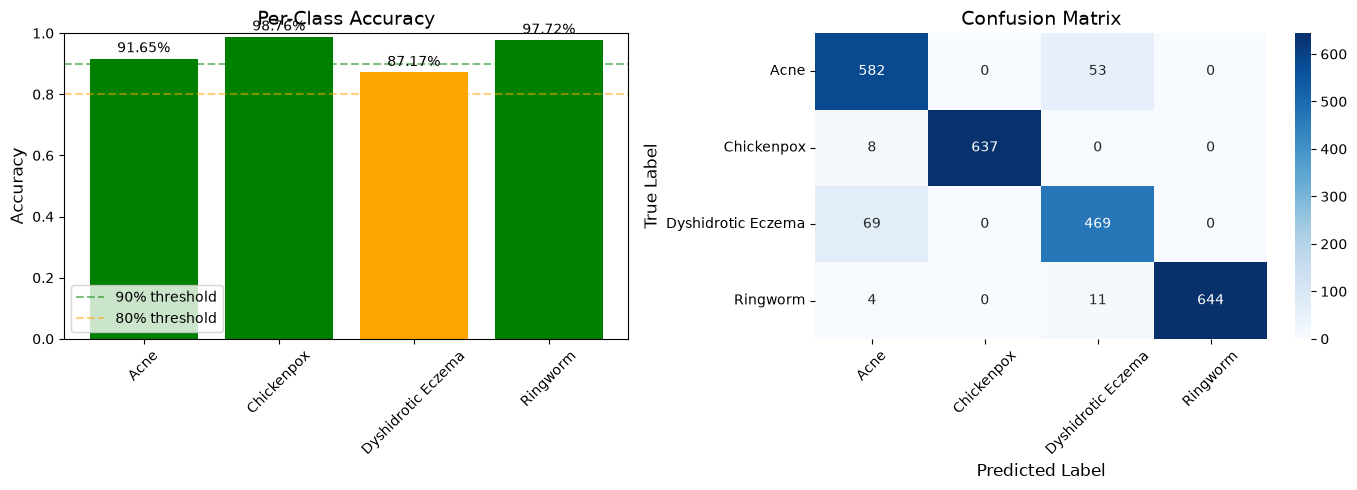


MODEL PERFORMANCE SUMMARY
✅ Best performing class: Chickenpox (98.76%)
📊 Worst performing class: Dyshidrotic Eczema (87.17%)
🎯 Overall Accuracy: 94.15%
📈 Training - Validation Gap: 1.35%


In [24]:
# Visual Summary
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Per-class accuracy bar chart
ax1 = axes[0]
per_class_acc = np.diag(cm) / np.sum(cm, axis=1)
colors = ['green' if acc > 0.90 else 'orange' if acc > 0.80 else 'red' for acc in per_class_acc]
bars = ax1.bar(class_names, per_class_acc, color=colors)
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.set_title('Per-Class Accuracy', fontsize=14)
ax1.set_ylim([0, 1.0])
ax1.axhline(y=0.90, color='green', linestyle='--', alpha=0.5, label='90% threshold')
ax1.axhline(y=0.80, color='orange', linestyle='--', alpha=0.5, label='80% threshold')
ax1.legend()
ax1.tick_params(axis='x', rotation=45)

# Add values on bars
for bar, acc in zip(bars, per_class_acc):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{acc:.2%}', ha='center', va='bottom', fontsize=10)

# 2. Confusion matrix heatmap
ax2 = axes[1]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            ax=ax2)
ax2.set_title('Confusion Matrix', fontsize=14)
ax2.set_xlabel('Predicted Label', fontsize=12)
ax2.set_ylabel('True Label', fontsize=12)
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Overall summary
print("\n" + "="*60)
print("MODEL PERFORMANCE SUMMARY")
print("="*60)
print(f"✅ Best performing class: {class_names[np.argmax(per_class_acc)]} ({max(per_class_acc):.2%})")
print(f"📊 Worst performing class: {class_names[np.argmin(per_class_acc)]} ({min(per_class_acc):.2%})")
print(f"🎯 Overall Accuracy: {np.sum(np.diag(cm)) / np.sum(cm):.2%}")
print(f"📈 Training - Validation Gap: {train_accuracy - val_accuracy:.2%}")

In [25]:
# Save model in different formats
print("SAVING MODEL")
print("="*40)

# 1. Save in Keras format (recommended)
model.save('skin_disease_model.keras')
print("✅ Model saved as 'skin_disease_model.keras'")

# 2. Save in H5 format (compatible)
model.save('skin_disease_model.h5')
print("✅ Model saved as 'skin_disease_model.h5'")

# 3. Save weights only (optional)
model.save_weights('model_weights.h5')
print("✅ Weights saved as 'model_weights.h5'")

print("\n📁 All files saved in current directory!")

SAVING MODEL
✅ Model saved as 'skin_disease_model.keras'
✅ Model saved as 'skin_disease_model.h5'


C:\Users\N TECH\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


✅ Weights saved as 'model_weights.h5'

📁 All files saved in current directory!


In [26]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

def test_single_image(img_path):
    try:
        # Load and preprocess image
        img = image.load_img(img_path, target_size=(224, 224))
        img_array = image.img_to_array(img)
        img_array = img_array / 255.0
        img_array = np.expand_dims(img_array, axis=0)
        
        # Predict
        predictions = model.predict(img_array, verbose=0)
        predicted_class = np.argmax(predictions[0])
        confidence = np.max(predictions[0]) * 100
        
        # Display results
        plt.figure(figsize=(8, 6))
        plt.imshow(img)
        plt.title(f'🔬 Prediction: {class_names[predicted_class]}\n📊 Confidence: {confidence:.2f}%',
                  fontsize=14, color='green' if confidence > 80 else 'orange')
        plt.axis('off')
        plt.show()
        
        # Show all class probabilities
        print("\n" + "="*50)
        print("📊 CLASS PROBABILITIES")
        print("="*50)
        for i, class_name in enumerate(class_names):
            prob = predictions[0][i] * 100
            bar = "█" * int(prob / 5)
            print(f"{class_name:25} : {prob:6.2f}% {bar}")
        
        print("\n" + "="*50)
        print(f"✅ Final Diagnosis: {class_names[predicted_class]}")
        print(f"📊 Confidence: {confidence:.2f}%")
        print("="*50)
        
        return class_names[predicted_class], confidence
        
    except Exception as e:
        print(f"❌ Error: {e}")
        print("Please check if the image path is correct!")

In [27]:
# Desktop par image test
test_single_image('C:/Users/N TECH/Desktop/acne.test.jpg')

❌ Error: Could not import PIL.Image. The use of `load_img` requires PIL.
Please check if the image path is correct!


In [28]:
!pip install Pillow

In [29]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

def test_single_image(img_path):
    try:
        # Load and preprocess image
        img = image.load_img(img_path, target_size=(224, 224))
        img_array = image.img_to_array(img)
        img_array = img_array / 255.0
        img_array = np.expand_dims(img_array, axis=0)
        
        # Predict
        predictions = model.predict(img_array, verbose=0)
        predicted_class = np.argmax(predictions[0])
        confidence = np.max(predictions[0]) * 100
        
        # Display results
        plt.figure(figsize=(8, 6))
        plt.imshow(img)
        plt.title(f'🔬 Prediction: {class_names[predicted_class]}\n📊 Confidence: {confidence:.2f}%',
                  fontsize=14, color='green' if confidence > 80 else 'orange')
        plt.axis('off')
        plt.show()
        
        # Show all class probabilities
        print("\n" + "="*50)
        print("📊 CLASS PROBABILITIES")
        print("="*50)
        for i, class_name in enumerate(class_names):
            prob = predictions[0][i] * 100
            bar = "█" * int(prob / 5)
            print(f"{class_name:25} : {prob:6.2f}% {bar}")
        
        print("\n" + "="*50)
        print(f"✅ Final Diagnosis: {class_names[predicted_class]}")
        print(f"📊 Confidence: {confidence:.2f}%")
        print("="*50)
        
        return class_names[predicted_class], confidence
        
    except Exception as e:
        print(f"❌ Error: {e}")
        print("Please check if the image path is correct!")

In [30]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

def test_single_image(img_path):
    try:
        # Load and preprocess image
        img = image.load_img(img_path, target_size=(224, 224))
        img_array = image.img_to_array(img)
        img_array = img_array / 255.0
        img_array = np.expand_dims(img_array, axis=0)
        
        # Predict
        predictions = model.predict(img_array, verbose=0)
        predicted_class = np.argmax(predictions[0])
        confidence = np.max(predictions[0]) * 100
        
        # Display results
        plt.figure(figsize=(8, 6))
        plt.imshow(img)
        plt.title(f'🔬 Prediction: {class_names[predicted_class]}\n📊 Confidence: {confidence:.2f}%',
                  fontsize=14, color='green' if confidence > 80 else 'orange')
        plt.axis('off')
        plt.show()
        
        # Show all class probabilities
        print("\n" + "="*50)
        print("📊 CLASS PROBABILITIES")
        print("="*50)
        for i, class_name in enumerate(class_names):
            prob = predictions[0][i] * 100
            bar_length = int(prob / 5)
            bar = "█" * bar_length
            print(f"{class_name:25} : {prob:6.2f}% {bar}")
        
        print("\n" + "="*50)
        print(f"✅ Final Diagnosis: {class_names[predicted_class]}")
        print(f"📊 Confidence: {confidence:.2f}%")
        print("="*50)
        
        return class_names[predicted_class], confidence
        
    except Exception as e:
        print(f"❌ Error: {e}")
        print("Please check if the image path is correct!")

# Test your image
test_single_image('C:/Users/N TECH/Desktop/acne.test.jpg')

❌ Error: Could not import PIL.Image. The use of `load_img` requires PIL.
Please check if the image path is correct!


In [31]:
!pip install opencv-python

   ---------------------------------------- 0.0/44.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/44.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/44.0 MB ? eta -:--:--
    --------------------------------------- 0.8/44.0 MB 2.1 MB/s eta 0:00:21
   - -------------------------------------- 1.3/44.0 MB 2.2 MB/s eta 0:00:20
   - -------------------------------------- 1.8/44.0 MB 2.2 MB/s eta 0:00:20
   -- ------------------------------------- 2.4/44.0 MB 2.3 MB/s eta 0:00:19
   -- ------------------------------------- 2.9/44.0 MB 2.3 MB/s eta 0:00:18
   --- ------------------------------------ 3.7/44.0 MB 2.5 MB/s eta 0:00:17
   --- ------------------------------------ 4.2/44.0 MB 2.5 MB/s eta 0:00:16
   ---- ----------------------------------- 4.7/44.0 MB 2.5 MB/s eta 0:00:16
   ----- ---------------------------------- 5.5/44.0 MB 2.6 MB/s eta 0:00:15
   ----- ---------------------------------- 6.3/44.0 MB 2.7 MB/s eta 0:00:14
   ------ ----------

  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-intel 2.15.0 requires numpy<2.0.0,>=1.23.5, but you have numpy 2.4.6 which is incompatible.


In [32]:
!pip uninstall numpy -y
!pip install numpy==1.24.3
!pip install opencv-python

Found existing installation: numpy 2.4.6
Uninstalling numpy-2.4.6:
  Successfully uninstalled numpy-2.4.6
   ---------------------------------------- 0.0/14.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/14.8 MB ? eta -:--:--
   - -------------------------------------- 0.5/14.8 MB 2.1 MB/s eta 0:00:07
   -- ------------------------------------- 0.8/14.8 MB 2.0 MB/s eta 0:00:08
   --- ------------------------------------ 1.3/14.8 MB 1.9 MB/s eta 0:00:08
   ---- ----------------------------------- 1.8/14.8 MB 2.0 MB/s eta 0:00:07
   ----- ---------------------------------- 2.1/14.8 MB 2.0 MB/s eta 0:00:07
   ------- -------------------------------- 2.6/14.8 MB 2.0 MB/s eta 0:00:06
   -------- ------------------------------- 3.1/14.8 MB 2.1 MB/s eta 0:00:06
   --------- ------------------------------ 3.7/14.8 MB 2.2 MB/s eta 0:00:06
   ----------- ---------------------------- 4.2/14.8 MB 2.2 MB/s eta 0:00:05
   ------------ --------------------------- 4.7/14.8 MB 2.2 M

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
contourpy 1.3.3 requires numpy>=1.25, but you have numpy 1.24.3 which is incompatible.
matplotlib 3.11.1 requires numpy>=1.25, but you have numpy 1.24.3 which is incompatible.
opencv-python 5.0.0.93 requires numpy>=2; python_version >= "3.9", but you have numpy 1.24.3 which is incompatible.
pandas 3.0.5 requires numpy>=1.26.0; python_version < "3.14", but you have numpy 1.24.3 which is incompatible.
scipy 1.17.1 requires numpy<2.7,>=1.26.4, but you have numpy 1.24.3 which is incompatible.


  Using cached numpy-2.4.6-cp311-cp311-win_amd64.whl.metadata (6.6 kB)
Using cached numpy-2.4.6-cp311-cp311-win_amd64.whl (12.6 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.24.3
    Uninstalling numpy-1.24.3:
      Successfully uninstalled numpy-1.24.3


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-intel 2.15.0 requires numpy<2.0.0,>=1.23.5, but you have numpy 2.4.6 which is incompatible.


In [33]:
import numpy as np
import cv2

print(f"✅ NumPy version: {np.__version__}")
print(f"✅ OpenCV version: {cv2.__version__}")
print(f"✅ TensorFlow imported successfully!")

✅ NumPy version: 1.26.4
✅ OpenCV version: 5.0.0
✅ TensorFlow imported successfully!


C:\Users\N TECH\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 128300 (\N{MICROSCOPE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\N TECH\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


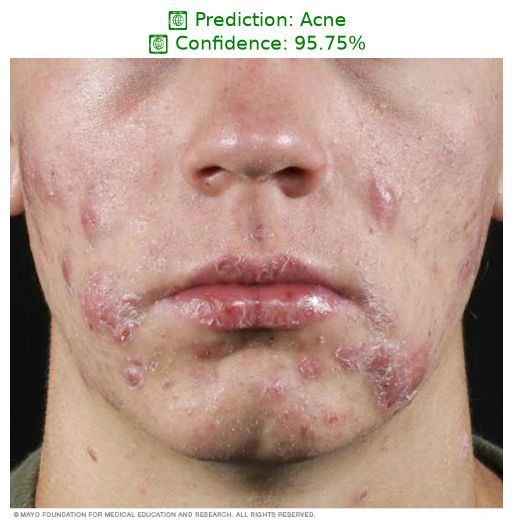


📊 CLASS PROBABILITIES
Acne                      :  95.75% ███████████████████
Chickenpox                :   0.03% 
Dyshidrotic Eczema        :   4.21% 
Ringworm                  :   0.01% 

✅ Final Diagnosis: Acne
📊 Confidence: 95.75%


In [34]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def test_image_opencv(img_path):
    try:
        # Load image using OpenCV
        img = cv2.imread(img_path)
        if img is None:
            print(f"❌ Image not found at: {img_path}")
            return None, 0
            
        # Convert BGR to RGB
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        # Preprocess
        img_resized = cv2.resize(img_rgb, (224, 224))
        img_array = img_resized.astype('float32') / 255.0
        img_array = np.expand_dims(img_array, axis=0)
        
        # Predict
        predictions = model.predict(img_array, verbose=0)
        predicted_class = np.argmax(predictions[0])
        confidence = np.max(predictions[0]) * 100
        
        # Display image
        plt.figure(figsize=(8, 6))
        plt.imshow(img_rgb)
        plt.title(f'🔬 Prediction: {class_names[predicted_class]}\n📊 Confidence: {confidence:.2f}%',
                  fontsize=14, color='green' if confidence > 80 else 'orange')
        plt.axis('off')
        plt.show()
        
        # Show probabilities
        print("\n" + "="*50)
        print("📊 CLASS PROBABILITIES")
        print("="*50)
        for i, class_name in enumerate(class_names):
            prob = predictions[0][i] * 100
            bar_length = int(prob / 5)
            bar = "█" * bar_length
            print(f"{class_name:25} : {prob:6.2f}% {bar}")
        
        print("\n" + "="*50)
        print(f"✅ Final Diagnosis: {class_names[predicted_class]}")
        print(f"📊 Confidence: {confidence:.2f}%")
        print("="*50)
        
        return class_names[predicted_class], confidence
        
    except Exception as e:
        print(f"❌ Error: {e}")
        return None, 0

# Test your image
result = test_image_opencv('C:/Users/N TECH/Desktop/acne.test.jpg')

In [35]:
import os

desktop = 'C:/Users/N TECH/Desktop/'

print("📁 Images on your desktop:")
print("="*40)

image_files = []
for f in os.listdir(desktop):
    if f.lower().endswith(('.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG')):
        image_files.append(f)
        print(f"   🖼️  {f}")

if not image_files:
    print("   ❌ No images found on desktop!")
    print("   Please download some images from Google.")
else:
    print(f"\n✅ Total {len(image_files)} images found!")

📁 Images on your desktop:
   🖼️  95019503-60d53500-0683-11eb-88a7-1aa51aa58d06.png
   🖼️  acne.test.jpg
   🖼️  acnee.test.jpg
   🖼️  ringwa.test.jpg
   🖼️  ringwarm.test.jpg

✅ Total 5 images found!


🖼️ TESTING ALL IMAGES FROM DESKTOP


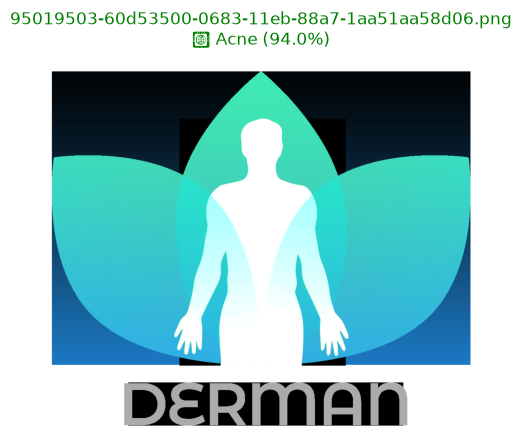


📊 95019503-60d53500-0683-11eb-88a7-1aa51aa58d06.png:
   Acne                :  94.0% ██████████████████
   Chickenpox          :   0.1% 
   Dyshidrotic Eczema  :   5.9% █
   Ringworm            :   0.0% 
----------------------------------------


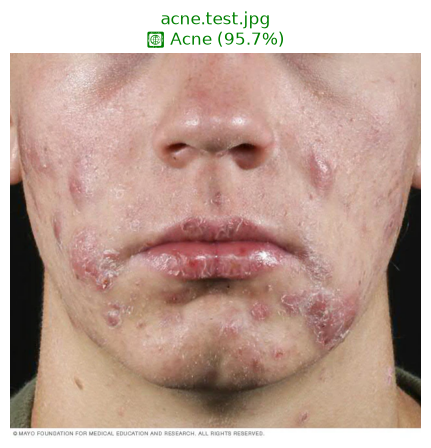


📊 acne.test.jpg:
   Acne                :  95.7% ███████████████████
   Chickenpox          :   0.0% 
   Dyshidrotic Eczema  :   4.2% 
   Ringworm            :   0.0% 
----------------------------------------


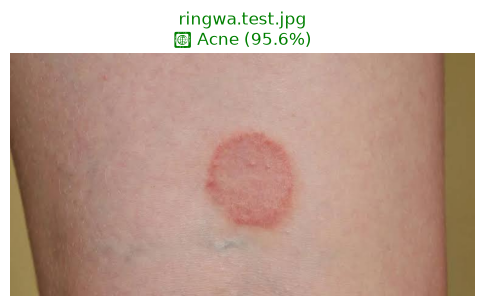


📊 ringwa.test.jpg:
   Acne                :  95.6% ███████████████████
   Chickenpox          :   0.0% 
   Dyshidrotic Eczema  :   4.4% 
   Ringworm            :   0.0% 
----------------------------------------


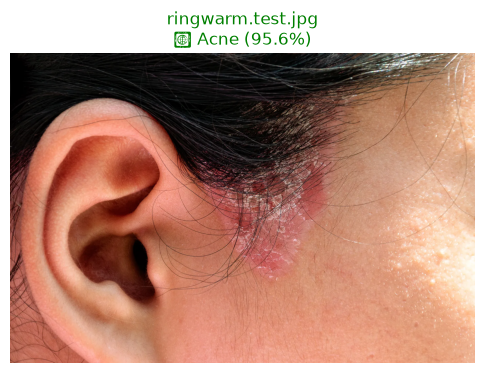


📊 ringwarm.test.jpg:
   Acne                :  95.6% ███████████████████
   Chickenpox          :   0.0% 
   Dyshidrotic Eczema  :   4.4% 
   Ringworm            :   0.0% 
----------------------------------------

📊 SUMMARY
   95019503-60d53500-0683-11eb-88a7-1aa51aa58d06.png → Acne            (94.0%)
   acne.test.jpg                  → Acne            (95.7%)
   ringwa.test.jpg                → Acne            (95.6%)
   ringwarm.test.jpg              → Acne            (95.6%)


In [36]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

def test_all_desktop_images():
    desktop = 'C:/Users/N TECH/Desktop/'
    
    print("🖼️ TESTING ALL IMAGES FROM DESKTOP")
    print("="*60)
    
    results = []
    
    for file in os.listdir(desktop):
        if file.lower().endswith(('.jpg', '.jpeg', '.png')):
            img_path = os.path.join(desktop, file)
            
            # Load image
            img = cv2.imread(img_path)
            if img is None:
                continue
                
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img_resized = cv2.resize(img_rgb, (224, 224))
            img_array = img_resized.astype('float32') / 255.0
            img_array = np.expand_dims(img_array, axis=0)
            
            # Predict
            predictions = model.predict(img_array, verbose=0)
            predicted_class = np.argmax(predictions[0])
            confidence = np.max(predictions[0]) * 100
            
            # Store result
            results.append({
                'file': file,
                'prediction': class_names[predicted_class],
                'confidence': confidence,
                'all_probs': predictions[0]
            })
            
            # Show image with prediction
            plt.figure(figsize=(6, 5))
            plt.imshow(img_rgb)
            plt.title(f'{file}\n🔬 {class_names[predicted_class]} ({confidence:.1f}%)',
                      fontsize=12, color='green' if confidence > 80 else 'orange')
            plt.axis('off')
            plt.show()
            
            # Show probabilities
            print(f"\n📊 {file}:")
            for i, class_name in enumerate(class_names):
                prob = predictions[0][i] * 100
                bar = "█" * int(prob / 5)
                print(f"   {class_name:20}: {prob:5.1f}% {bar}")
            print("-"*40)
    
    # Summary
    print("\n" + "="*60)
    print("📊 SUMMARY")
    print("="*60)
    for r in results:
        print(f"   {r['file']:30} → {r['prediction']:15} ({r['confidence']:.1f}%)")
    
    return results

# Run test
results = test_all_desktop_images()

In [1]:
print("🖼️ TESTING RANDOM IMAGES FROM VALIDATION SET")
print("="*50)

import random

for images, labels in val_ds.take(2):
    for i in range(min(3, len(images))):
        idx = random.randint(0, len(images)-1)
        img = images[idx].numpy()
        true_label = class_names[labels[idx].numpy()]
        
        pred = model.predict(np.expand_dims(img, axis=0), verbose=0)
        pred_class = class_names[np.argmax(pred[0])]
        conf = np.max(pred[0]) * 100
        
        plt.figure(figsize=(5, 5))
        plt.imshow(img)
        plt.title(f'True: {true_label}\nPred: {pred_class}\nConf: {conf:.1f}%',
                  color='green' if true_label == pred_class else 'red')
        plt.axis('off')
        plt.show()

🖼️ TESTING RANDOM IMAGES FROM VALIDATION SET


NameError: name 'val_ds' is not defined

In [2]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Dataset path
dataset_path = 'C:/Users/N TECH/Desktop/skin disease dataset/dataset'

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Data augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

# Load training data
train_ds = train_datagen.flow_from_directory(
    dataset_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    subset='training',
    shuffle=True
)

# Load validation data
val_ds = val_datagen.flow_from_directory(
    dataset_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    subset='validation',
    shuffle=False
)

class_names = list(train_ds.class_indices.keys())
print(f"✅ Classes: {class_names}")
print(f"✅ Training samples: {train_ds.samples}")
print(f"✅ Validation samples: {val_ds.samples}")


Found 9910 images belonging to 4 classes.
Found 2476 images belonging to 4 classes.
✅ Classes: ['Acne', 'Chickenpox', 'Dyshidrotic Eczema', 'Ringworm']
✅ Training samples: 9910
✅ Validation samples: 2476


In [3]:
import random
import matplotlib.pyplot as plt
import numpy as np

print("🖼️ TESTING RANDOM IMAGES FROM VALIDATION SET")
print("="*50)

# Total images to test
num_images = 5
tested = 0
correct = 0

for images, labels in val_ds:
    for i in range(len(images)):
        if tested >= num_images:
            break
            
        idx = i
        img = images[idx].numpy()
        true_label = class_names[labels[idx].numpy()]
        
        # Predict
        pred = model.predict(np.expand_dims(img, axis=0), verbose=0)
        pred_class = class_names[np.argmax(pred[0])]
        conf = np.max(pred[0]) * 100
        
        # Show image
        plt.figure(figsize=(5, 5))
        plt.imshow(img)
        plt.title(f'True: {true_label}\nPred: {pred_class}\nConf: {conf:.1f}%',
                  color='green' if true_label == pred_class else 'red')
        plt.axis('off')
        plt.show()
        
        if true_label == pred_class:
            correct += 1
            
        tested += 1
    
    if tested >= num_images:
        break

print(f"\n📊 Accuracy: {correct}/{tested} = {correct/tested*100:.1f}%")

🖼️ TESTING RANDOM IMAGES FROM VALIDATION SET


AttributeError: 'numpy.ndarray' object has no attribute 'numpy'

In [4]:
print("🖼️ TESTING ALL VALIDATION IMAGES")
print("="*50)

y_true = []
y_pred_classes = []
total_batches = 0

for images, labels in val_ds:
    total_batches += 1
    predictions = model.predict(images, verbose=0)
    predicted_classes = np.argmax(predictions, axis=1)
    
    y_true.extend(labels.numpy())
    y_pred_classes.extend(predicted_classes)
    
    if total_batches % 10 == 0:
        print(f"  Processed {total_batches} batches...")

# Convert to numpy arrays
y_true = np.array(y_true)
y_pred_classes = np.array(y_pred_classes)

# Calculate accuracy
accuracy = np.mean(y_true == y_pred_classes)
print(f"\n✅ Total validation samples: {len(y_true)}")
print(f"✅ Validation Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

# Per-class accuracy
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_true, y_pred_classes)

print("\n📊 PER-CLASS ACCURACY:")
print("-"*40)
for i, class_name in enumerate(class_names):
    correct = cm[i, i]
    total = np.sum(cm[i, :])
    acc = correct / total
    print(f"   {class_name:20}: {acc:.2%} ({correct}/{total})")

🖼️ TESTING ALL VALIDATION IMAGES


NameError: name 'model' is not defined

In [5]:
import os

print("🔍 SEARCHING FOR MODEL FILE")
print("="*50)

# Check current directory
current_dir = os.getcwd()
print(f"📁 Current Directory: {current_dir}")

# Check common locations
locations = [
    current_dir,
    'C:/Users/N TECH/Desktop',
    'C:/Users/N TECH/Downloads',
    'C:/Users/N TECH/Documents',
    'C:/Users/N TECH'
]

found_files = []

for loc in locations:
    if os.path.exists(loc):
        print(f"\n📂 Checking: {loc}")
        for file in os.listdir(loc):
            if file.endswith(('.keras', '.h5')):
                full_path = os.path.join(loc, file)
                size = os.path.getsize(full_path) / (1024 * 1024)
                found_files.append(full_path)
                print(f"   ✅ {file} ({size:.2f} MB)")

if found_files:
    print("\n" + "="*50)
    print("📁 FOUND MODEL FILES:")
    for f in found_files:
        print(f"   {f}")
else:
    print("\n❌ No model files found!")
    print("\n💡 Possible reasons:")
    print("   1. Model was never saved")
    print("   2. Model saved in different folder")
    print("   3. Model file was deleted")

🔍 SEARCHING FOR MODEL FILE
📁 Current Directory: C:\Users\N TECH\Desktop\skin disease dataset

📂 Checking: C:\Users\N TECH\Desktop\skin disease dataset

📂 Checking: C:/Users/N TECH/Desktop

📂 Checking: C:/Users/N TECH/Downloads

📂 Checking: C:/Users/N TECH/Documents

📂 Checking: C:/Users/N TECH
   ✅ .keras (0.00 MB)
   ✅ model_weights.h5 (9.46 MB)
   ✅ skin_disease_model.h5 (10.84 MB)
   ✅ skin_disease_model.keras (11.02 MB)

📁 FOUND MODEL FILES:
   C:/Users/N TECH\.keras
   C:/Users/N TECH\model_weights.h5
   C:/Users/N TECH\skin_disease_model.h5
   C:/Users/N TECH\skin_disease_model.keras


In [6]:
from tensorflow.keras.models import load_model
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os

# MODEL KA SAHI PATH - YAHAN SE LOAD KARENGE
model_path = 'C:/Users/N TECH/skin_disease_model.keras'

# Check if file exists
if os.path.exists(model_path):
    print(f"✅ Model found at: {model_path}")
    model = load_model(model_path)
    print("✅ Model loaded successfully!")
else:
    print(f"❌ Model not found at: {model_path}")
    # Try alternative path
    model_path = 'C:/Users/N TECH/skin_disease_model.h5'
    if os.path.exists(model_path):
        print(f"✅ Model found at: {model_path}")
        model = load_model(model_path)
    else:
        print("❌ Model not found anywhere!")
        exit()

# Class names
class_names = ['Acne', 'Chickenpox', 'Dyshidrotic Eczema', 'Ringworm']
print(f"✅ Classes: {class_names}")

# Test function
def test_image_opencv(img_path):
    try:
        img = cv2.imread(img_path)
        if img is None:
            print(f"❌ Image not found at: {img_path}")
            return None, 0
            
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img_resized = cv2.resize(img_rgb, (224, 224))
        img_array = img_resized.astype('float32') / 255.0
        img_array = np.expand_dims(img_array, axis=0)
        
        predictions = model.predict(img_array, verbose=0)
        predicted_class = np.argmax(predictions[0])
        confidence = np.max(predictions[0]) * 100
        
        plt.figure(figsize=(8, 6))
        plt.imshow(img_rgb)
        plt.title(f'🔬 Prediction: {class_names[predicted_class]}\n📊 Confidence: {confidence:.2f}%',
                  fontsize=14, color='green' if confidence > 80 else 'orange')
        plt.axis('off')
        plt.show()
        
        print("\n" + "="*50)
        print("📊 CLASS PROBABILITIES")
        print("="*50)
        for i, class_name in enumerate(class_names):
            prob = predictions[0][i] * 100
            bar = "█" * int(prob / 5)
            print(f"{class_name:25} : {prob:6.2f}% {bar}")
        
        print("\n" + "="*50)
        print(f"✅ Final Diagnosis: {class_names[predicted_class]}")
        print(f"📊 Confidence: {confidence:.2f}%")
        print("="*50)
        
        return class_names[predicted_class], confidence
        
    except Exception as e:
        print(f"❌ Error: {e}")
        return None, 0

print("\n🎉 Model ready! Use: test_image_opencv('image_path.jpg')")

✅ Model found at: C:/Users/N TECH/skin_disease_model.keras


✅ Model loaded successfully!
✅ Classes: ['Acne', 'Chickenpox', 'Dyshidrotic Eczema', 'Ringworm']

🎉 Model ready! Use: test_image_opencv('image_path.jpg')


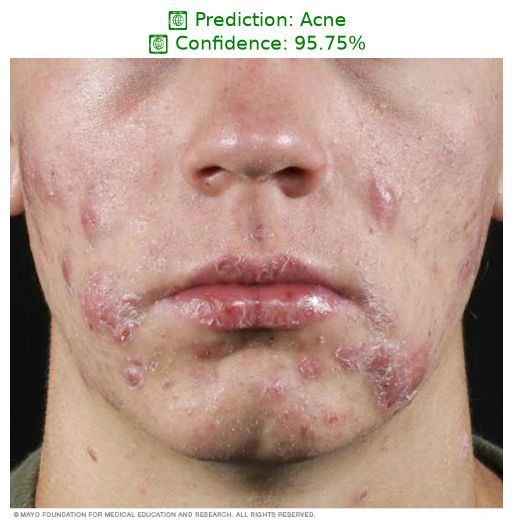


📊 CLASS PROBABILITIES
Acne                      :  95.75% ███████████████████
Chickenpox                :   0.03% 
Dyshidrotic Eczema        :   4.21% 
Ringworm                  :   0.01% 

✅ Final Diagnosis: Acne
📊 Confidence: 95.75%


('Acne', 95.74798941612244)

In [11]:
# Test your image
test_image_opencv('C:/Users/N TECH/Desktop/acne.test.jpg')

In [12]:
import os

# APNA DATASET PATH
dataset_path = 'C:/Users/N TECH/Desktop/skin disease dataset/dataset'

print("📁 CHECKING DATASET STRUCTURE")
print("="*50)

if os.path.exists(dataset_path):
    print(f"✅ Dataset found at: {dataset_path}\n")
    
    # Check classes
    classes = os.listdir(dataset_path)
    print(f"📂 Classes found: {classes}")
    print("-"*40)
    
    total_images = 0
    for cls in classes:
        cls_path = os.path.join(dataset_path, cls)
        if os.path.isdir(cls_path):
            images = [f for f in os.listdir(cls_path) 
                     if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
            count = len(images)
            total_images += count
            print(f"   {cls:25} : {count:4} images")
    
    print("-"*40)
    print(f"   {'TOTAL':25} : {total_images:4} images")
    print("="*50)
else:
    print(f"❌ Dataset not found at: {dataset_path}")
    print("Please check the path!")

📁 CHECKING DATASET STRUCTURE
✅ Dataset found at: C:/Users/N TECH/Desktop/skin disease dataset/dataset

📂 Classes found: ['Acne', 'Chickenpox', 'Dyshidrotic Eczema', 'Ringworm']
----------------------------------------
   Acne                      : 3283 images
   Chickenpox                : 3293 images
   Dyshidrotic Eczema        : 2600 images
   Ringworm                  : 3210 images
----------------------------------------
   TOTAL                     : 12386 images


In [13]:
# ============================================
# COMPLETE TRAINING CODE
# ============================================

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import matplotlib.pyplot as plt
import numpy as np
import os

print("="*60)
print("🚀 SKIN DISEASE CLASSIFIER TRAINING")
print("="*60)

# ============================================
# 1. DATASET PATH
# ============================================

dataset_path = 'C:/Users/N TECH/Desktop/skin disease dataset/dataset'

# Check if dataset exists
if not os.path.exists(dataset_path):
    print(f"❌ Dataset not found at: {dataset_path}")
    exit()

print(f"✅ Dataset found: {dataset_path}")

# ============================================
# 2. PARAMETERS
# ============================================

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 20

# ============================================
# 3. DATA AUGMENTATION & LOADING
# ============================================

# Data augmentation for training (more variety)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    validation_split=0.2  # 80% training, 20% validation
)

# Only rescaling for validation
val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

# Load training data
train_ds = train_datagen.flow_from_directory(
    dataset_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    subset='training',
    shuffle=True
)

# Load validation data
val_ds = val_datagen.flow_from_directory(
    dataset_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    subset='validation',
    shuffle=False
)

class_names = list(train_ds.class_indices.keys())
print(f"\n✅ Classes: {class_names}")
print(f"✅ Training samples: {train_ds.samples}")
print(f"✅ Validation samples: {val_ds.samples}")

# ============================================
# 4. BUILD MODEL
# ============================================

print("\n🔧 Building model...")

model = models.Sequential([
    # Convolutional layers
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(256, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    # Flatten and dense layers
    layers.Flatten(),
    layers.Dropout(0.5),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(len(class_names), activation='softmax')
])

# Compile model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()
print("✅ Model built successfully!")

# ============================================
# 5. CALLBACKS (Save best model)
# ============================================

callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    ModelCheckpoint('best_skin_model.keras', save_best_only=True)
]

# ============================================
# 6. TRAIN MODEL
# ============================================

print("\n🚀 Training started...")
print("="*60)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

print("\n✅ Training Complete!")
print("="*60)

# ============================================
# 7. SAVE MODEL
# ============================================

model.save('C:/Users/N TECH/Desktop/skin_disease_model_new.keras')
print("✅ Model saved to Desktop as 'skin_disease_model_new.keras'")

# ============================================
# 8. PLOT RESULTS
# ============================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
ax1.plot(history.history['accuracy'], label='Training Accuracy', marker='o')
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='s')
ax1.set_title('Model Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

# Loss plot
ax2.plot(history.history['loss'], label='Training Loss', marker='o')
ax2.plot(history.history['val_loss'], label='Validation Loss', marker='s')
ax2.set_title('Model Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

# ============================================
# 9. FINAL RESULTS
# ============================================

train_acc = history.history['accuracy'][-1]
val_acc = history.history['val_accuracy'][-1]
train_loss = history.history['loss'][-1]
val_loss = history.history['val_loss'][-1]

print("\n" + "="*60)
print("📊 FINAL RESULTS")
print("="*60)
print(f"✅ Training Accuracy:   {train_acc:.4f} ({train_acc*100:.2f}%)")
print(f"✅ Validation Accuracy: {val_acc:.4f} ({val_acc*100:.2f}%)")
print(f"📉 Training Loss:       {train_loss:.4f}")
print(f"📉 Validation Loss:     {val_loss:.4f}")
print(f"📊 Accuracy Gap:        {(train_acc - val_acc)*100:.2f}%")

if train_acc - val_acc < 0.05:
    print("✅ No significant overfitting!")
else:
    print("⚠️ Possible overfitting detected!")

🚀 SKIN DISEASE CLASSIFIER TRAINING
✅ Dataset found: C:/Users/N TECH/Desktop/skin disease dataset/dataset
Found 9910 images belonging to 4 classes.
Found 2476 images belonging to 4 classes.

✅ Classes: ['Acne', 'Chickenpox', 'Dyshidrotic Eczema', 'Ringworm']
✅ Training samples: 9910
✅ Validation samples: 2476

🔧 Building model...

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 222, 222, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2  (None, 111, 111, 32)      0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 109, 109, 64)      18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 54, 54, 64)       

KeyboardInterrupt: 

In [ ]:
 # Load trained model
from tensorflow.keras.models import load_model

model = load_model('C:/Users/N TECH/Desktop/skin_disease_model_new.keras')
print("✅ Model loaded!")

# Test function
def test_image_opencv(img_path):
    import cv2
    import numpy as np
    import matplotlib.pyplot as plt
    
    img = cv2.imread(img_path)
    if img is None:
        print(f"❌ Image not found: {img_path}")
        return
    
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (224, 224))
    img_array = img_resized.astype('float32') / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    
    predictions = model.predict(img_array, verbose=0)
    pred_class = class_names[np.argmax(predictions[0])]
    confidence = np.max(predictions[0]) * 100
    
    plt.figure(figsize=(8, 6))
    plt.imshow(img_rgb)
    plt.title(f'🔬 Prediction: {pred_class}\n📊 Confidence: {confidence:.2f}%',
              color='green' if confidence > 80 else 'orange')
    plt.axis('off')
    plt.show()
    
    print("\n" + "="*50)
    print("📊 CLASS PROBABILITIES")
    print("="*50)
    for i, class_name in enumerate(class_names):
        prob = predictions[0][i] * 100
        bar = "█" * int(prob / 5)
        print(f"{class_name:25} : {prob:6.2f}% {bar}")
    
    print("\n" + "="*50)
    print(f"✅ Final Diagnosis: {pred_class}")
    print(f"📊 Confidence: {confidence:.2f}%")
    print("="*50)

# Test an image
test_image_opencv('C:/Users/N TECH/Desktop/acne.test.jpg')